# Sistem Peringatan Dini Kerusakan Komponen Mesin Motor Matic Berbasis Audio
**Klasifikasi:** `Tensioner_Aus` (Label 0) vs `Gardan` (Label 1)  
**Metode:** CNN-1D (varian ANN) + MFCC + Delta + Delta-Delta (librosa)  

In [43]:
#IMPORT & GLOBAL SEED

import os
import glob
import warnings
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f'✅ TensorFlow: {tf.__version__} | librosa: {librosa.__version__}')

✅ TensorFlow: 2.21.0 | librosa: 0.11.0


In [44]:
#KONFIGURASI DATASET

DATA_DIR = "Dataset"

CLASS_FOLDERS = {
    0: "Tensioner_Aus",
    1: "Gardan"
}

# Parameter audio
SR              = 22050
N_MFCC          = 40
N_FFT           = 2048
HOP_LENGTH      = 512
TARGET_DURATION = 3.0   

In [45]:
#FUNGSI LOAD AUDIO
def load_audio_fixed(path, sr=SR, duration=TARGET_DURATION):
    """
    Memuat audio .wav dengan panjang tetap 'duration' detik.
    Cropping dari tengah (lebih representatif dari crop di awal).
    File gagal dibaca → return None (dilewati).
    """
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
        target_len = int(sr * duration)
        if len(y) >= target_len:
            start = (len(y) - target_len) // 2
            y = y[start : start + target_len]
        else:
            pad = target_len - len(y)
            y = np.pad(y, (pad // 2, pad - pad // 2), mode='constant')
        return y.astype(np.float32)
    except Exception as e:
        print(f'[SKIP] {os.path.basename(path)}: {e}')
        return None

In [46]:
#AUGMENTASI DI LEVEL AUDIO RAW
def augment_audio(y, sr=SR):
    """
    Augmentasi sinyal audio raw.
    Tiga jenis augmentasi dipilih secara acak:
      1. Gaussian noise  — simulasi noise lingkungan
      2. Time stretch    — simulasi variasi kecepatan mesin
      3. Pitch shift     — simulasi variasi beban mesin
    """
    choice = np.random.randint(0, 3)
    target_len = len(y)

    if choice == 0:
        # Tambah noise Gaussian (SNR sekitar 20dB)
        noise = np.random.randn(len(y)).astype(np.float32) * 0.005
        y_aug = y + noise

    elif choice == 1:
        # Time stretch ±10% (simulasi variasi RPM mesin)
        rate = np.random.uniform(0.9, 1.1)
        y_aug = librosa.effects.time_stretch(y, rate=rate)
        # Paksa kembali ke panjang semula
        if len(y_aug) > target_len:
            y_aug = y_aug[:target_len]
        else:
            y_aug = np.pad(y_aug, (0, target_len - len(y_aug)), mode='constant')

    else:
        # Pitch shift ±2 semitone (simulasi variasi beban)
        steps = np.random.uniform(-2, 2)
        y_aug = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

    return y_aug.astype(np.float32)

In [47]:
# =========================================
# CELL 5 — build_dataset (GANTI SELURUH ISI)
# Sekarang mengembalikan TIGA output:
#   X_raw  : list array MFCC temporal (N, T, F)
#   y      : array label
#   audio_raw_list : list sinyal audio 1D float32 ← INI yang dipakai augmentasi
# =========================================
def extract_mfcc_temporal_with_delta(y_signal, sr=SR, n_mfcc=N_MFCC,
                                      n_fft=N_FFT, hop_length=HOP_LENGTH):
    min_samples = n_fft
    if len(y_signal) < min_samples:
        y_signal = np.pad(y_signal, (0, min_samples - len(y_signal)), mode='constant')

    mfcc = librosa.feature.mfcc(y=y_signal, sr=sr, n_mfcc=n_mfcc,
                                 n_fft=n_fft, hop_length=hop_length)
    T = mfcc.shape[1]
    delta_width = min(9, T)
    if delta_width % 2 == 0:
        delta_width = max(3, delta_width - 1)
    if T < 3:
        mfcc = np.pad(mfcc, ((0, 0), (0, 3 - T)), mode='edge')
        delta_width = 3

    delta  = librosa.feature.delta(mfcc, width=delta_width)
    delta2 = librosa.feature.delta(mfcc, width=delta_width, order=2)
    features = np.concatenate([mfcc, delta, delta2], axis=0).T
    return features.astype(np.float32)


def build_dataset(data_dir, class_folders):
    """
    Mengembalikan:
      X_feat_list  : list array MFCC (T, 3*n_mfcc) per file
      y            : array label int64
      audio_list   : list sinyal audio 1D float32 ← untuk augmentasi raw
    """
    X_feat_list = []
    audio_list  = []   # ← sinyal raw disimpan di sini
    y_list      = []

    for label, folder in class_folders.items():
        folder_path = os.path.join(data_dir, folder)
        wav_paths   = sorted(glob.glob(os.path.join(folder_path, '*.wav')))
        print(f"Memproses kelas '{folder}' (label={label}): {len(wav_paths)} file")
        for p in wav_paths:
            y_sig = load_audio_fixed(p)   # sinyal 1D float32
            if y_sig is None:
                continue
            feat = extract_mfcc_temporal_with_delta(y_sig)
            X_feat_list.append(feat)
            audio_list.append(y_sig)      # simpan sinyal raw-nya
            y_list.append(label)

    y = np.array(y_list, dtype=np.int64)
    print(f"Total valid: {len(y)} | Shape fitur[0]: {X_feat_list[0].shape}")
    return X_feat_list, y, audio_list    # ← tiga return value


# Jalankan ulang
X_raw, y, audio_raw_list = build_dataset(DATA_DIR, CLASS_FOLDERS)

Memproses kelas 'Tensioner_Aus' (label=0): 170 file
Memproses kelas 'Gardan' (label=1): 136 file
Total valid: 306 | Shape fitur[0]: (130, 120)


In [48]:
# =========================================
# CELL 6 — SPLIT (GANTI SELURUH ISI)
# =========================================
indices = np.arange(len(y))

idx_trainval, idx_test = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=y
)

X_raw_trainval = [X_raw[i] for i in idx_trainval]
X_raw_test     = [X_raw[i] for i in idx_test]
y_trainval     = y[idx_trainval]
y_test         = y[idx_test]

# ← INI YANG HILANG SEBELUMNYA: pisahkan sinyal raw sesuai split
audio_raw_trainval = [audio_raw_list[i] for i in idx_trainval]  # list sinyal 1D
audio_raw_test     = [audio_raw_list[i] for i in idx_test]

# max_len HANYA dari train+val
MAX_LEN = max(seq.shape[0] for seq in X_raw_trainval)
print(f'MAX_LEN: {MAX_LEN} frames')

X_trainval = pad_sequences_to_maxlen(X_raw_trainval, MAX_LEN)
X_test     = pad_sequences_to_maxlen(X_raw_test,     MAX_LEN)

print(f'Train+Val: {X_trainval.shape} | Test: {X_test.shape}')
print(f'audio_raw_trainval: {len(audio_raw_trainval)} sinyal 1D')

MAX_LEN: 130 frames
Train+Val: (260, 130, 120) | Test: (46, 130, 120)
audio_raw_trainval: 260 sinyal 1D


In [49]:
#ARSITEKTUR CNN-1D
def build_cnn1d(input_shape, l2_reg=1e-4, dropout_rate=0.3):
    """
    CNN-1D untuk klasifikasi sekuens temporal MFCC.
    Input shape: (n_frames, n_features)
    """
    model = models.Sequential(name='CNN1D_Motor_Matic')

    # --- Blok Konvolusi 1 ---
    # kernel_size=5: menangkap pola lokal dalam 5 frame (~116ms pada 22050Hz/512hop)
    model.add(layers.Conv1D(32, kernel_size=5, activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(l2_reg),
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(dropout_rate))

    # --- Blok Konvolusi 2 ---
    # kernel_size=3: menangkap pola lebih abstrak setelah pooling
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(dropout_rate))

    # --- Blok Konvolusi 3 ---
    model.add(layers.Conv1D(128, kernel_size=3, activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate + 0.1))  # dropout lebih agresif di layer dalam

    # --- Global Average Pooling: meringkas seluruh sekuens temporal ---
    model.add(layers.GlobalAveragePooling1D())

    # --- Dense Head ---
    model.add(layers.Dense(64, activation='relu',
                           kernel_regularizer=regularizers.l2(l2_reg)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))  # output biner

    return model

# Preview arsitektur
sample_input_shape = (X_trainval.shape[1], X_trainval.shape[2])
preview_model = build_cnn1d(sample_input_shape)
preview_model.summary()
print(f'\nInput shape per sampel: {sample_input_shape}')

Model: "CNN1D_Motor_Matic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 130, 32)        │        19,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 130, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 65, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 65, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 65, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 65, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 32, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,361 (231.88 KB)

 Trainable params: 58,913 (230.13 KB)

 Non-trainable params: 448 (1.75 KB)


Input shape per sampel: (130, 120)


In [50]:
#NORMALISASI PER-FOLD 
def normalize_3d_per_channel(X_train_3d, X_val_3d):
    """
    Normalisasi StandardScaler per feature channel.
    PENTING: scaler di-fit HANYA dari X_train_3d.
    X shape: (samples, time_frames, features)
    """
    n_train, T, F = X_train_3d.shape
    n_val         = X_val_3d.shape[0]

    # Reshape ke 2D untuk StandardScaler
    X_tr_2d  = X_train_3d.reshape(-1, F)
    X_val_2d = X_val_3d.reshape(-1, F)

    scaler = StandardScaler()
    X_tr_norm  = scaler.fit_transform(X_tr_2d).reshape(n_train, T, F)  # fit+transform HANYA train
    X_val_norm = scaler.transform(X_val_2d).reshape(n_val, T, F)       # transform saja untuk val

    return X_tr_norm, X_val_norm, scaler  # kembalikan scaler untuk dipakai di test set

In [51]:
# AUGMENTASI AUDIO RAW 
def augment_and_extract(y_signal, sr=SR, aug_prob=0.5):
    """
    Augmentasi sinyal audio raw, lalu ekstraksi MFCC.
    aug_prob: probabilitas augmentasi diterapkan.

    Penyebab ParameterError delta sebelumnya:
      librosa.effects.time_stretch menghasilkan array dengan panjang
      berbeda dari sinyal asli (len(y_aug) != target_len) jika rate != 1.0.
      Jika hasilnya sangat pendek (jarang tapi mungkin dengan rate tinggi
      dan sinyal pendek), MFCC hanya menghasilkan 1 frame sehingga
      librosa.feature.delta gagal karena width=9 > n_frames.
      Solusi: selalu normalisasi ulang panjang sinyal SETELAH augmentasi
      ke target_len yang pasti, sebelum masuk ke MFCC extractor.
    """
    target_len = len(y_signal)

    if np.random.rand() < aug_prob:
        choice = np.random.randint(0, 3)

        if choice == 0:
            # Gaussian noise — panjang tidak berubah, aman
            noise    = (np.random.randn(target_len) * 0.005).astype(np.float32)
            y_signal = y_signal + noise

        elif choice == 1:
            # Time stretch — panjang output BISA berbeda; selalu paksa ke target_len
            rate  = np.random.uniform(0.9, 1.1)
            y_aug = librosa.effects.time_stretch(y=y_signal, rate=rate)
            if len(y_aug) >= target_len:
                y_signal = y_aug[:target_len]
            else:
                pad_amt  = target_len - len(y_aug)
                y_signal = np.pad(y_aug, (0, pad_amt), mode='constant')

        else:
            # Pitch shift — panjang sama dengan input, aman
            steps    = np.random.uniform(-2, 2)
            y_signal = librosa.effects.pitch_shift(y=y_signal, sr=sr, n_steps=steps)

    # Pastikan panjang selalu tepat target_len sebelum ekstraksi MFCC
    y_signal = y_signal.astype(np.float32)
    if len(y_signal) > target_len:
        y_signal = y_signal[:target_len]
    elif len(y_signal) < target_len:
        y_signal = np.pad(y_signal, (0, target_len - len(y_signal)), mode='constant')

    return extract_mfcc_temporal_with_delta(y_signal)

In [52]:
# 10) STRATIFIED K-FOLD CV + AKUMULASI PREDIKSI
def train_with_cv(X_all, y_all, X_raw_list, n_splits=5):
    """
    X_all     : array (N, T, F) — MFCC temporal dari train+val set
    y_all     : array (N,)      — label
    X_raw_list: list of raw audio arrays — untuk augmentasi yang benar
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    cv_accuracies  = []
    all_val_true   = []  # ← DIKUMPULKAN dari semua fold
    all_val_pred   = []  # ← DIKUMPULKAN dari semua fold
    best_scaler    = None
    best_model     = None
    best_acc       = -1

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
        print(f'\n[Fold {fold+1}/{n_splits}]')

        X_train_fold, X_val_fold = X_all[train_idx], X_all[val_idx]
        y_train_fold, y_val_fold = y_all[train_idx], y_all[val_idx]

        # --- Augmentasi dari raw audio (hanya untuk train) ---
        X_train_aug_list = []
        y_train_aug_list = []
        for i, raw_idx in enumerate(train_idx):
            X_train_aug_list.append(X_train_fold[i])
            y_train_aug_list.append(y_train_fold[i])
            # 50% chance augmentasi
            if np.random.rand() < 0.5:
                aug_feat = augment_and_extract(X_raw_list[raw_idx])
                # Pad/crop ke MAX_LEN
                T_aug = aug_feat.shape[0]
                T_target = X_all.shape[1]
                if T_aug >= T_target:
                    aug_feat = aug_feat[:T_target, :]
                else:
                    aug_feat = np.pad(aug_feat, ((0, T_target - T_aug), (0, 0)))
                X_train_aug_list.append(aug_feat)
                y_train_aug_list.append(y_train_fold[i])

        X_train_aug = np.array(X_train_aug_list, dtype=np.float32)
        y_train_aug = np.array(y_train_aug_list, dtype=np.int64)

        # --- Normalisasi: fit HANYA dari train fold ---
        X_train_norm, X_val_norm, fold_scaler = normalize_3d_per_channel(X_train_aug, X_val_fold)

        # --- Build & kompilasi model baru per fold ---
        model = build_cnn1d(input_shape=(X_train_norm.shape[1], X_train_norm.shape[2]))
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        # --- Callbacks ---
        early_stop = EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True, verbose=0)
        reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=5, min_lr=1e-6, verbose=0)

        # --- Training ---
        history = model.fit(
            X_train_norm, y_train_aug,
            validation_data=(X_val_norm, y_val_fold),
            epochs=80, batch_size=16,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # --- Evaluasi fold ---
        y_pred_fold = (model.predict(X_val_norm, verbose=0) >= 0.5).astype(int).flatten()
        acc = accuracy_score(y_val_fold, y_pred_fold)
        cv_accuracies.append(acc)

        # KUNCI: akumulasi prediksi dari SETIAP fold ke dalam satu list
        all_val_true.extend(y_val_fold.tolist())
        all_val_pred.extend(y_pred_fold.tolist())

        # Simpan model dan scaler dari fold terbaik
        if acc > best_acc:
            best_acc    = acc
            best_model  = model
            best_scaler = fold_scaler

        epochs_run = len(history.history['loss'])
        print(f'  ↳ Val Accuracy: {acc*100:.2f}% | Epochs: {epochs_run}')

    print(f'MEAN CV ACCURACY: {np.mean(cv_accuracies)*100:.2f}% (±{np.std(cv_accuracies)*100:.2f}%)')
    
    return best_model, best_scaler, np.array(all_val_true), np.array(all_val_pred), cv_accuracies


# Jalankan training
# X_raw_trainval: list sinyal audio raw (untuk augmentasi)
best_model, best_scaler, all_true_cv, all_pred_cv, cv_accs = train_with_cv(
    X_trainval, y_trainval, audio_raw_trainval, n_splits=5   
)


[Fold 1/5]
  ↳ Val Accuracy: 100.00% | Epochs: 29

[Fold 2/5]
  ↳ Val Accuracy: 98.08% | Epochs: 19

[Fold 3/5]
  ↳ Val Accuracy: 100.00% | Epochs: 80

[Fold 4/5]
  ↳ Val Accuracy: 96.15% | Epochs: 13

[Fold 5/5]
  ↳ Val Accuracy: 96.15% | Epochs: 17
MEAN CV ACCURACY: 98.08% (±1.72%)


In [53]:
#CLASSIFICATION REPORT CROSS-VALIDATION
class_labels = ['Tensioner_Aus (0)', 'Gardan (1)']
cv_acc_total = accuracy_score(all_true_cv, all_pred_cv)

print(f'\n=== EVALUASI CROSS-VALIDATION (GABUNGAN 5 FOLD) ===')
print(f'Akurasi Gabungan CV : {cv_acc_total*100:.2f}%')
print(f'Total sampel        : {len(all_true_cv)}')
print()
print(classification_report(all_true_cv, all_pred_cv,
                            target_names=class_labels, digits=4))


=== EVALUASI CROSS-VALIDATION (GABUNGAN 5 FOLD) ===
Akurasi Gabungan CV : 98.08%
Total sampel        : 260

                   precision    recall  f1-score   support

Tensioner_Aus (0)     0.9860    0.9792    0.9826       144
       Gardan (1)     0.9744    0.9828    0.9785       116

         accuracy                         0.9808       260
        macro avg     0.9802    0.9810    0.9806       260
     weighted avg     0.9808    0.9808    0.9808       260



In [54]:
#EVALUASI AKHIR PADA HELD-OUT TEST SET

# Normalisasi test set menggunakan scaler dari fold terbaik
n_test = X_test.shape[0]
T, F   = X_test.shape[1], X_test.shape[2]
X_test_norm = best_scaler.transform(X_test.reshape(-1, F)).reshape(n_test, T, F)

# Prediksi
y_prob_test = best_model.predict(X_test_norm, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_pred_test)

print(f'  AKURASI HELD-OUT TEST SET: {test_acc*100:.2f}%')
print(f'  (n={len(y_test)} sampel yang tidak pernah dilihat model)')
print()
print(classification_report(y_test, y_pred_test,
                            target_names=class_labels, digits=4))


  AKURASI HELD-OUT TEST SET: 100.00%
  (n=46 sampel yang tidak pernah dilihat model)

                   precision    recall  f1-score   support

Tensioner_Aus (0)     1.0000    1.0000    1.0000        26
       Gardan (1)     1.0000    1.0000    1.0000        20

         accuracy                         1.0000        46
        macro avg     1.0000    1.0000    1.0000        46
     weighted avg     1.0000    1.0000    1.0000        46



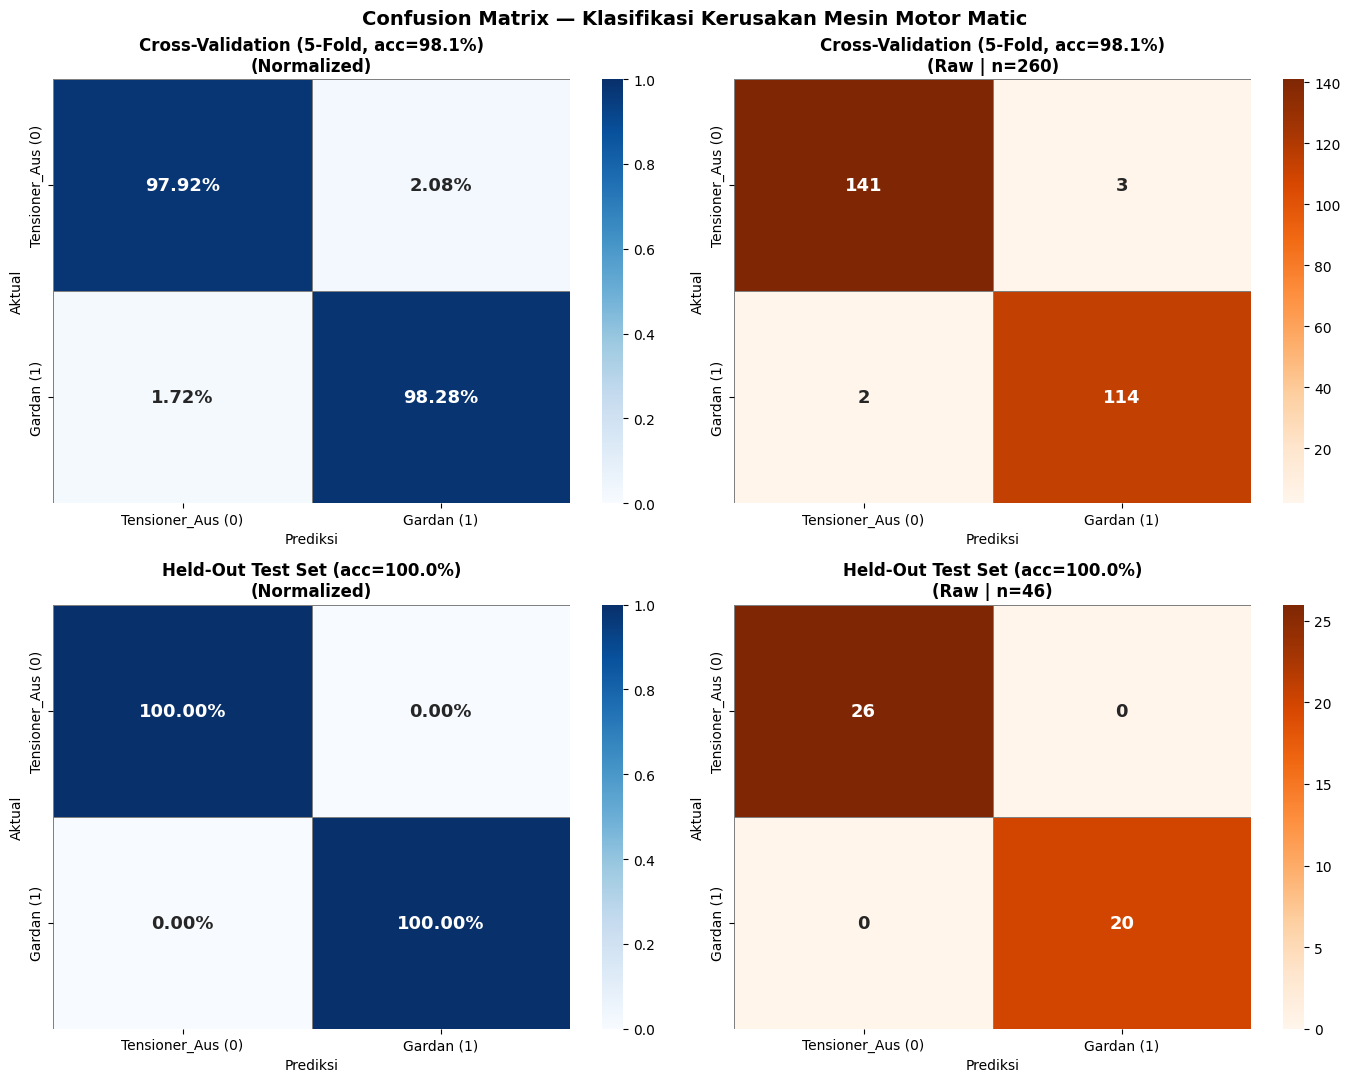

In [55]:
#VISUALISASI CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred, title, class_labels, axes):
    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                linewidths=0.5, linecolor='gray',
                xticklabels=class_labels, yticklabels=class_labels,
                vmin=0, vmax=1, ax=axes[0], annot_kws={'size': 13, 'weight': 'bold'})
    axes[0].set_title(f'{title}\n(Normalized)', fontweight='bold')
    axes[0].set_ylabel('Aktual')
    axes[0].set_xlabel('Prediksi')

    # Raw
    sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Oranges',
                linewidths=0.5, linecolor='gray',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[1], annot_kws={'size': 13, 'weight': 'bold'})
    axes[1].set_title(f'{title}\n(Raw | n={len(y_true)})', fontweight='bold')
    axes[1].set_ylabel('Aktual')
    axes[1].set_xlabel('Prediksi')


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrix — Klasifikasi Kerusakan Mesin Motor Matic',
             fontsize=14, fontweight='bold')

plot_confusion_matrix(all_true_cv,  all_pred_cv,
                      f'Cross-Validation (5-Fold, acc={np.mean(cv_accs)*100:.1f}%)',
                      class_labels, axes[0])

plot_confusion_matrix(y_test, y_pred_test,
                      f'Held-Out Test Set (acc={test_acc*100:.1f}%)',
                      class_labels, axes[1])

plt.tight_layout()
plt.show()

In [56]:
#SIMPAN MODEL & SCALER
import pickle

MODEL_PATH  = 'model_motor_matic_cnn1d.h5'
SCALER_PATH = 'scaler_motor_matic.pkl'

best_model.save(MODEL_PATH)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(best_scaler, f)

print(f'Model tersimpan  : {MODEL_PATH}')
print(f'Scaler tersimpan : {SCALER_PATH}')
print(f'   (MAX_LEN untuk inference: {MAX_LEN})')

# Simpan konfigurasi agar deployment (penggunaan aplikasi) konsisten
with open('model_config.pkl', 'wb') as f:
    pickle.dump({'MAX_LEN': MAX_LEN, 'N_MFCC': N_MFCC, 'SR': SR,
                 'N_FFT': N_FFT, 'HOP_LENGTH': HOP_LENGTH,
                 'TARGET_DURATION': TARGET_DURATION}, f)

Model tersimpan  : model_motor_matic_cnn1d.h5
Scaler tersimpan : scaler_motor_matic.pkl
   (MAX_LEN untuk inference: 130)


In [57]:
#FUNGSI PREDIKSI UNTUK DEPLOYMENT

def predict_single_audio(wav_path, model, scaler, max_len,
                          sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT,
                          hop_length=HOP_LENGTH, duration=TARGET_DURATION):
    """
    Memprediksi satu file .wav.
    Mengembalikan dict dengan label, nama kelas, dan probabilitas.
    """
    y_sig = load_audio_fixed(wav_path, sr=sr, duration=duration)
    if y_sig is None:
        return {'error': f'File tidak bisa dibaca: {wav_path}'}

    feat = extract_mfcc_temporal_with_delta(y_sig)

    # Pad/crop ke max_len
    T_actual = feat.shape[0]
    F        = feat.shape[1]
    if T_actual >= max_len:
        feat = feat[:max_len, :]
    else:
        feat = np.pad(feat, ((0, max_len - T_actual), (0, 0)), mode='constant')

    # Normalisasi menggunakan scaler yang sama dengan training
    feat_norm = scaler.transform(feat.reshape(-1, F)).reshape(1, max_len, F)

    # Prediksi
    prob  = float(model.predict(feat_norm, verbose=0)[0][0])
    label = 1 if prob >= 0.5 else 0
    kelas = {0: 'Tensioner_Aus', 1: 'Gardan'}[label]

    return {
        'label'        : label,
        'kelas'        : kelas,
        'probabilitas' : prob,
        'keyakinan'    : f'{max(prob, 1-prob)*100:.1f}%'
    }

In [58]:
#RINGKASAN AKHIR
print('='*60)
print('  RINGKASAN PROYEK AKHIR')
print('='*60)
print(f'  Arsitektur     : CNN-1D (varian ANN) — 3 blok konvolusi')
print(f'  Fitur          : MFCC + Delta + Delta2, shape ({MAX_LEN}, {N_MFCC*3})')
print(f'  Total sampel   : {len(y)} ({len(y_trainval)} train+val / {len(y_test)} test)')
print(f'  Augmentasi     : Raw audio (noise, time-stretch, pitch-shift)')
print(f'  CV Mean Acc    : {np.mean(cv_accs)*100:.2f}% ± {np.std(cv_accs)*100:.2f}%')
print(f'  Test Acc       : {test_acc*100:.2f}% (n={len(y_test)}, BELUM PERNAH dilihat model)')
print(f'  Status         : {status}')
print('='*60)

  RINGKASAN PROYEK AKHIR
  Arsitektur     : CNN-1D (varian ANN) — 3 blok konvolusi
  Fitur          : MFCC + Delta + Delta2, shape (130, 120)
  Total sampel   : 306 (260 train+val / 46 test)
  Augmentasi     : Raw audio (noise, time-stretch, pitch-shift)
  CV Mean Acc    : 98.08% ± 1.72%
  Test Acc       : 100.00% (n=46, BELUM PERNAH dilihat model)
  Status         : ✅ MEMENUHI SYARAT (≥70%)
